In [2]:
import torch
from torch.utils.data import Dataset


class FMRIDataset(Dataset):
    """
    Dataset for 3D fMRI volumes.
    Input shape:
        (N, 64, 64, 34)

    Returned shape:
        (1, 64, 64, 34)
    """

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        volume = self.X[idx]

        # Add channel dimension
        volume = volume.unsqueeze(0)

        label = self.y[idx]

        return volume, label


if __name__ == "__main__":

    import numpy as np

    X = np.load("prepared_data/X_train.npy")
    y = np.load("prepared_data/y_train.npy")

    dataset = FMRIDataset(X, y)

    print("Dataset size:", len(dataset))

    volume, label = dataset[0]

    print("Volume shape:", volume.shape)
    print("Label:", label)

Dataset size: 147
Volume shape: torch.Size([1, 64, 64, 34])
Label: tensor(0)


In [3]:
import torch
import torch.nn as nn


class FMRI3DCNN(nn.Module):

    def __init__(self):

        super(FMRI3DCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv3d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(16),

            nn.ReLU(inplace=True),

            nn.MaxPool3d(2),

            nn.Conv3d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool3d(2),

            nn.Conv3d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool3d(2),

            nn.AdaptiveAvgPool3d(1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64, 64),

            nn.ReLU(inplace=True),

            nn.Dropout(0.5),

            nn.Linear(64, 2)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


if __name__ == "__main__":

    model = FMRI3DCNN()

    dummy = torch.randn(
        2,
        1,
        64,
        64,
        34
    )

    output = model(dummy)

    print("Output shape:", output.shape)

Output shape: torch.Size([2, 2])


In [4]:
import json
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from torch.utils.data import DataLoader

X_test = np.load("prepared_data/X_test.npy")
y_test = np.load("prepared_data/y_test.npy")

dataset = FMRIDataset(X_test,y_test)

loader = DataLoader(
    dataset,
    batch_size=2
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = FMRI3DCNN()

model.load_state_dict(
    torch.load(
        "results/model_3dcnn.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

predictions = []

with torch.no_grad():

    for X_batch,_ in loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        preds = outputs.argmax(1)

        predictions.extend(
            preds.cpu().numpy()
        )

acc = accuracy_score(
    y_test,
    predictions
)

cm = confusion_matrix(
    y_test,
    predictions
)

report = classification_report(
    y_test,
    predictions,
    output_dict=True
)

print("Accuracy:",acc)

metrics = {
    "accuracy": float(acc),
    "confusion_matrix": cm.tolist(),
    "report": report
}

with open(
    "results/metrics.json",
    "w"
) as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20508\722872146.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


Accuracy: 0.7567567567567568


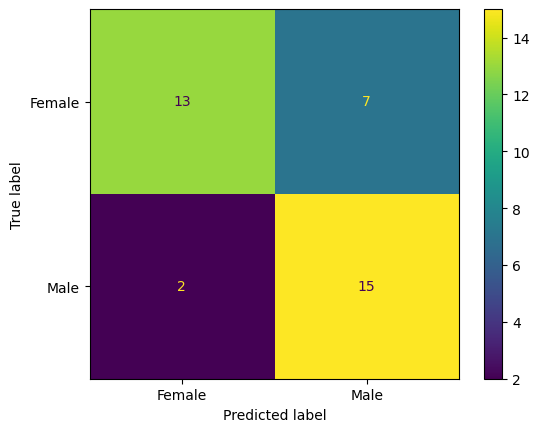

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Female","Male"]
)

disp.plot()

plt.savefig(
    "results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
import json

metrics = {

    "accuracy": float(acc),

    "classification_report":
    classification_report(
        y_test,
        predictions,
        output_dict=True
    )
}

with open(
    "results/metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )